# Classification on raw data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import sys
import I2MC

### processing raw data

In [47]:
first_df = pd.read_csv("/home/yoannl/code/drealKn/DyslexIA/data/data/Subject_1003_T1_Syllables_raw.csv")
first_df.head()

,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,stimfile,subject_id
0,328491191,146.24,155.97,161.65,161.52,4.43,4.17,s7_stimuli_t1.jpg,1003
1,328495189,145.10,155.34,159.05,162.17,4.44,4.17,s7_stimuli_t1.jpg,1003
2,328499187,142.61,153.04,160.49,162.19,4.45,4.16,s7_stimuli_t1.jpg,1003
3,328503186,141.55,149.98,162.91,162.88,4.45,4.16,s7_stimuli_t1.jpg,1003
4,328507184,139.31,146.80,163.20,163.24,4.46,4.16,s7_stimuli_t1.jpg,1003


In [48]:
first_df.shape

(18247, 9)

First try without considering the time serie
- Need to transform lines into rows of vectors at instant T
- Add a time column
- Considerate different sizes of data

In [49]:
# ── I2MC / recording parameters ───────────────────────────────────────────────
FREQ_HZ      = 250
MIN_FIX_MS   = 40
SCREEN_X     = 1920
SCREEN_Y     = 1080
MISSING_VAL  = -32768

In [50]:
def run_i2mc(raw_df):
    gaze = pd.DataFrame({
        'time': raw_df['time'] / 1000.0,   # µs → ms
        'L_X' : raw_df['gaze_x_left'],
        'L_Y' : raw_df['gaze_y_left'],
        'R_X' : raw_df['gaze_x_right'],
        'R_Y' : raw_df['gaze_y_right'],
    })
    options = {
        'xres'        : SCREEN_X,
        'yres'        : SCREEN_Y,
        'freq'        : FREQ_HZ,
        'missingx'    : MISSING_VAL,
        'missingy'    : MISSING_VAL,
        'minFixDur'   : MIN_FIX_MS,
        'maxMergeDist': 30,
        'maxMergeTime': 30,
    }
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        result = I2MC.I2MC(gaze, options, logging=False)

    if result is False or result[0] is False:
        sys.exit("I2MC clustering failed.")
    fix, _, _ = result
    return fix

In [51]:
test = pd.DataFrame(run_i2mc(first_df))
test

,cutoff,start,end,startT,endT,dur,xpos,ypos,flankdataloss,fracinterped,RMSxy,BCEA,fixRangeX,fixRangeY
0,1.196773,0,48,328491.191,328687.161,195.970,161.4900,170.9400,0.0,0.0,1.791551,208.708809,22.055,26.200
1,1.196773,61,134,328735.174,329031.196,296.022,339.2375,172.3700,0.0,0.0,1.465907,189.734786,27.420,19.965
2,1.196773,144,233,329067.199,329427.074,359.875,450.5950,168.0200,0.0,0.0,2.182556,384.854079,36.845,24.430
3,1.196773,248,313,329483.064,329747.066,264.002,582.0225,161.0100,0.0,0.0,1.708638,65.726844,15.750,13.755
4,1.196773,321,402,329775.070,330103.084,328.014,467.2600,168.2525,0.0,0.0,2.041138,171.982212,23.775,26.200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,1.196773,17514,17540,398541.124,398649.089,107.965,0.0000,0.0000,0.0,0.0,0.000000,NaN,0.000,0.000
132,1.196773,17579,17748,398801.054,399481.006,679.952,1071.9175,840.4350,0.0,0.0,1.471911,119.378759,23.480,19.200
133,1.196773,17754,17888,399501.007,400040.935,539.928,1199.5400,852.6650,0.0,0.0,1.985245,346.075349,42.590,20.285
134,1.196773,17894,18123,400060.939,400980.971,920.032,1342.0175,852.6650,0.0,0.0,2.028166,555.539153,67.950,27.305


In [52]:
def transform_raw_data(df, subject_id):
    df['gaze'] = df[['dur', 'xpos', 'ypos']].values.tolist()
    df = df.explode('gaze').reset_index(drop=True)
    row_df = df.iloc[:, -1].to_frame().T.reset_index(drop=True)
    row_df.insert(0, 'subject_id', subject_id)
    return row_df

In [53]:
test2 = transform_raw_data(test, 1003)
test2

,subject_id,0,1,2,3,4,5,6,7,8,...,398,399,400,401,402,403,404,405,406,407
0,1003,195.97,161.49,170.94,296.022,339.2375,172.37,359.875,450.595,168.02,...,840.435,539.928,1199.54,852.665,920.032,1342.0175,852.665,459.791,1519.51,918.97


### Testing on another subject

In [54]:
second_df = pd.read_csv("/home/yoannl/code/drealKn/DyslexIA/data/data/Subject_1996_T1_Syllables_raw.csv")
second_df.shape

(21458, 9)

In [55]:
second_fix = pd.DataFrame(run_i2mc(second_df))
second_transformed = transform_raw_data(second_fix,1996)
second_transformed.head()

,subject_id,0,1,2,3,4,5,6,7,8,...,572,573,574,575,576,577,578,579,580,581
0,1996,99.985,162.63,168.35,151.981,308.5375,210.8025,543.878,343.3225,157.7875,...,0.0,732.215,1237.25,831.47,1855.845,1331.705,841.39,287.737,1521.13,901.1625


### Testing concatenation of the two transformed dataframes

In [56]:
concat = pd.concat([test2, second_transformed], ignore_index=True)
concat.head()

,subject_id,0,1,2,3,4,5,6,7,8,...,572,573,574,575,576,577,578,579,580,581
0,1003,195.97,161.49,170.94,296.022,339.2375,172.37,359.875,450.595,168.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1996,99.985,162.63,168.35,151.981,308.5375,210.8025,543.878,343.3225,157.7875,...,0.0,732.215,1237.25,831.47,1855.845,1331.705,841.39,287.737,1521.13,901.1625


### Iterating over files

In [57]:
import re
import os

In [58]:
concat = pd.DataFrame()
for filename in os.listdir("/home/yoannl/code/drealKn/DyslexIA/data/data/"):
    if re.match(r"Subject_\d+_T\d+_Syllables_raw\.csv", filename):
        df = pd.read_csv(os.path.join("/home/yoannl/code/drealKn/DyslexIA/data/data/", filename))
        fix = pd.DataFrame(run_i2mc(df))
        subject_id = re.search(r"_\d+_", filename)[0].strip("_")
        row_df = transform_raw_data(fix, subject_id)
        concat = pd.concat([concat, row_df], ignore_index=True)
concat.head()

,subject_id,0,1,2,3,4,5,6,7,8,...,989,990,991,992,993,994,995,996,997,998
0,1312,235.988,153.92,141.935,79.985,426.8675,248.6125,499.879,352.485,172.91,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1350,175.889,151.905,104.2175,116.038,465.105,163.665,311.825,332.78,122.1725,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1134,115.964,166.1,150.61,127.987,479.665,240.535,71.999,371.235,162.3725,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1095,311.924,142.27,144.6475,339.943,347.43,153.55,304.025,466.85,163.755,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1300,275.991,166.26,148.83,448.084,371.28,192.125,139.98,477.865,159.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
concat.shape

(70, 1000)

In [60]:
concat = concat.sort_values(by='subject_id').reset_index(drop=True)
concat.fillna(0, inplace=True)
concat.head()

/tmp/ipykernel_159341/639935377.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  concat.fillna(0, inplace=True)


,subject_id,0,1,2,3,4,5,6,7,8,...,989,990,991,992,993,994,995,996,997,998
0,1003,195.970,161.4900,170.940,296.022,339.2375,172.370,359.875,450.5950,168.0200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1009,236.012,133.7450,116.670,155.855,366.7550,138.655,255.989,325.7350,135.1525,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1016,176.034,146.8025,165.515,124.016,570.1550,283.495,95.989,411.7075,198.3450,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1019,211.955,150.0000,142.220,139.964,394.1950,183.110,280.005,351.5575,154.4425,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1021,175.835,146.6875,149.450,111.993,541.2625,340.210,76.005,379.6950,201.5150,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
y = pd.read_csv("/home/yoannl/code/drealKn/DyslexIA/data/dyslexia_class_label.csv")
y = y.drop(columns=['subject_id', 'label'])
X = concat.drop(columns=['subject_id'])
X.columns = X.columns.astype(str)

## First test SVC without scaling

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [63]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

/home/yoannl/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [64]:
y_pred = model.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Accuracy =', round(accuracy_score(y_test, y_pred), 2)) # Accuracy

print('Precision =', round(precision_score(y_test, y_pred), 2)) # Precision

print('Recall =', round(recall_score(y_test, y_pred), 2)) # Recall

print('F1 score =', round(f1_score(y_test, y_pred), 2)) # F1 score

Accuracy = 0.67
Precision = 0.62
Recall = 0.56
F1 score = 0.59


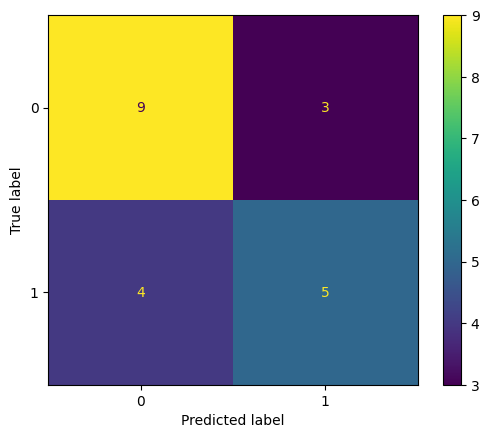

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [67]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, X, y.values.ravel(), cv=3, scoring=['accuracy', 'precision', 'recall', 'f1'])
print('Cross-validated Accuracy =', round(cv_results['test_accuracy'].mean(), 2))
print('Cross-validated Precision =', round(cv_results['test_precision'].mean(), 2))
print('Cross-validated Recall =', round(cv_results['test_recall'].mean(), 2))
print('Cross-validated F1 score =', round(cv_results['test_f1'].mean(), 2))

Cross-validated Accuracy = 0.66
Cross-validated Precision = 0.68
Cross-validated Recall = 0.57
Cross-validated F1 score = 0.61


## SVC with scaling

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
model = SVC(kernel='linear')
model.fit(X_train, y_train.values.ravel())
y_pred = model.predict(X_test)

In [71]:
print('Accuracy =', round(accuracy_score(y_test, y_pred), 2)) # Accuracy

print('Precision =', round(precision_score(y_test, y_pred), 2)) # Precision

print('Recall =', round(recall_score(y_test, y_pred), 2)) # Recall

print('F1 score =', round(f1_score(y_test, y_pred), 2)) # F1 score

Accuracy = 0.67
Precision = 0.62
Recall = 0.56
F1 score = 0.59


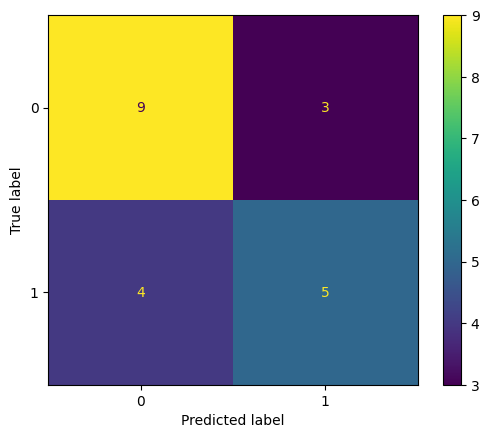

In [72]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [73]:
X_scaled = scaler.fit_transform(X)

cv_results = cross_validate(model, X, y.values.ravel(), cv=3, scoring=['accuracy', 'precision', 'recall', 'f1'])
print('Cross-validated Accuracy =', round(cv_results['test_accuracy'].mean(), 2))
print('Cross-validated Precision =', round(cv_results['test_precision'].mean(), 2))
print('Cross-validated Recall =', round(cv_results['test_recall'].mean(), 2))
print('Cross-validated F1 score =', round(cv_results['test_f1'].mean(), 2))

Cross-validated Accuracy = 0.66
Cross-validated Precision = 0.68
Cross-validated Recall = 0.57
Cross-validated F1 score = 0.61


## Testing KNN

In [3]:
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
knn = KNeighborsClassifier(n_neighbors=1)
cv = cross_val_predict(knn, X_scaled, y.values.ravel(), cv=3, method='predict_proba')
cv = np.argmax(cv, axis=1)
print("Confusion Matrix (3 neighbors):\n", pd.crosstab(cv, y.values.ravel()), sep="")

NameError: name 'X_scaled' is not defined

In [76]:
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier

classifier = KNeighborsTimeSeriesClassifier(distance="euclidean")
classifier.fit(X_train_scaled, y_train.values.ravel())
y_pred = classifier.predict(X_test_scaled)


In [77]:
print('Accuracy =', round(accuracy_score(y_test, y_pred), 2)) # Accuracy

print('Precision =', round(precision_score(y_test, y_pred), 2)) # Precision

print('Recall =', round(recall_score(y_test, y_pred), 2)) # Recall

print('F1 score =', round(f1_score(y_test, y_pred), 2)) # F1 score

Accuracy = 0.52
Precision = 0.45
Recall = 0.56
F1 score = 0.5


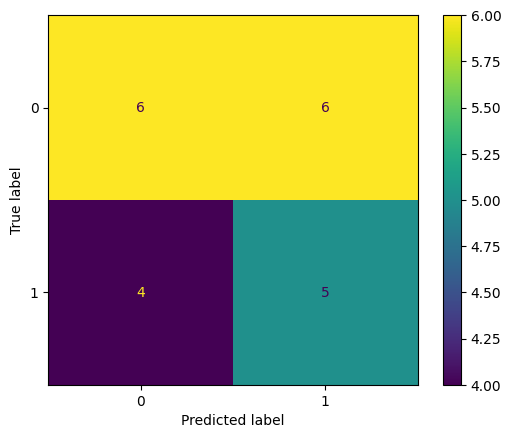

In [78]:
ConfusionMatrixDisplay.from_estimator(classifier, X_test_scaled, y_test)

I don't think we can work only on raw data
It seems that fixations are necessary to classify correctly

## Testing RNN  

In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, GRU, LSTM
from tensorflow.keras.utils import pad_sequences
import tensorflow as tf
import os
import re

I0000 00:00:1780471990.580963   25657 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
df = pd.read_csv("/home/yoannl/code/drealKn/DyslexIA/data/data/Subject_1003_T1_Syllables_raw.csv")
df.head()


,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,stimfile,subject_id
0,328491191,146.24,155.97,161.65,161.52,4.43,4.17,s7_stimuli_t1.jpg,1003
1,328495189,145.10,155.34,159.05,162.17,4.44,4.17,s7_stimuli_t1.jpg,1003
2,328499187,142.61,153.04,160.49,162.19,4.45,4.16,s7_stimuli_t1.jpg,1003
3,328503186,141.55,149.98,162.91,162.88,4.45,4.16,s7_stimuli_t1.jpg,1003
4,328507184,139.31,146.80,163.20,163.24,4.46,4.16,s7_stimuli_t1.jpg,1003


In [7]:
df["dt"] = df["time"].diff().fillna(0)
df.head()

,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,stimfile,subject_id,dt
0,328491191,146.24,155.97,161.65,161.52,4.43,4.17,s7_stimuli_t1.jpg,1003,0.0
1,328495189,145.10,155.34,159.05,162.17,4.44,4.17,s7_stimuli_t1.jpg,1003,3998.0
2,328499187,142.61,153.04,160.49,162.19,4.45,4.16,s7_stimuli_t1.jpg,1003,3998.0
3,328503186,141.55,149.98,162.91,162.88,4.45,4.16,s7_stimuli_t1.jpg,1003,3999.0
4,328507184,139.31,146.80,163.20,163.24,4.46,4.16,s7_stimuli_t1.jpg,1003,3998.0


In [8]:
df["vlx"] = df["gaze_x_left"].diff() / df["dt"]
df["vly"] = df["gaze_y_left"].diff() / df["dt"]
df["vrx"] = df["gaze_x_right"].diff() / df["dt"]
df["vry"] = df["gaze_y_right"].diff() / df["dt"]
df.head()

,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,stimfile,subject_id,dt,vlx,vly,vrx,vry
0,328491191,146.24,155.97,161.65,161.52,4.43,4.17,s7_stimuli_t1.jpg,1003,0.0,NaN,NaN,NaN,NaN
1,328495189,145.10,155.34,159.05,162.17,4.44,4.17,s7_stimuli_t1.jpg,1003,3998.0,-0.000285,-0.000158,-0.000650,0.000163
2,328499187,142.61,153.04,160.49,162.19,4.45,4.16,s7_stimuli_t1.jpg,1003,3998.0,-0.000623,-0.000575,0.000360,0.000005
3,328503186,141.55,149.98,162.91,162.88,4.45,4.16,s7_stimuli_t1.jpg,1003,3999.0,-0.000265,-0.000765,0.000605,0.000173
4,328507184,139.31,146.80,163.20,163.24,4.46,4.16,s7_stimuli_t1.jpg,1003,3998.0,-0.000560,-0.000795,0.000073,0.000090


In [9]:
df["disp_x"] = df["gaze_x_left"] - df["gaze_x_right"]
df["disp_y"] = df["gaze_y_left"] - df["gaze_y_right"]
df.head()

,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,stimfile,subject_id,dt,vlx,vly,vrx,vry,disp_x,disp_y
0,328491191,146.24,155.97,161.65,161.52,4.43,4.17,s7_stimuli_t1.jpg,1003,0.0,NaN,NaN,NaN,NaN,-15.41,-5.55
1,328495189,145.10,155.34,159.05,162.17,4.44,4.17,s7_stimuli_t1.jpg,1003,3998.0,-0.000285,-0.000158,-0.000650,0.000163,-13.95,-6.83
2,328499187,142.61,153.04,160.49,162.19,4.45,4.16,s7_stimuli_t1.jpg,1003,3998.0,-0.000623,-0.000575,0.000360,0.000005,-17.88,-9.15
3,328503186,141.55,149.98,162.91,162.88,4.45,4.16,s7_stimuli_t1.jpg,1003,3999.0,-0.000265,-0.000765,0.000605,0.000173,-21.36,-12.90
4,328507184,139.31,146.80,163.20,163.24,4.46,4.16,s7_stimuli_t1.jpg,1003,3998.0,-0.000560,-0.000795,0.000073,0.000090,-23.89,-16.44


In [10]:
def transform_raw_data_rnn(df, subject_id):
    df["dt"] = df["time"].diff().fillna(0)
    df["vlx"] = df["gaze_x_left"].diff() / df["dt"]
    df["vly"] = df["gaze_y_left"].diff() / df["dt"]
    df["vrx"] = df["gaze_x_right"].diff() / df["dt"]
    df["vry"] = df["gaze_y_right"].diff() / df["dt"]
    df["disp_x"] = df["gaze_x_left"] - df["gaze_x_right"]
    df["disp_y"] = df["gaze_y_left"] - df["gaze_y_right"]
    df = df.drop(columns=['time', 'pupil_left', 'pupil_right', 'stimfile'])

    return df


In [11]:
sequences = []

for filename in os.listdir("/home/yoannl/code/drealKn/DyslexIA/data/data/"):
    if re.match(r"Subject_\d+_T\d+_Syllables_raw\.csv", filename):
        df = pd.read_csv(os.path.join("/home/yoannl/code/drealKn/DyslexIA/data/data/", filename))
        subject_id = re.search(r"_\d+_", filename)[0].strip("_")
        transformed_df = transform_raw_data_rnn(df, subject_id)
        sequences.append(transformed_df)

sequences[0].shape

(41151, 12)

In [12]:
sequences[0].shape

(41151, 12)

In [13]:
y = pd.read_csv("/home/yoannl/code/drealKn/DyslexIA/data/dyslexia_class_label.csv")
y = y.drop(columns=['subject_id', 'label'])

In [14]:
max_len = max(len(s) for s in sequences)
n_features = sequences[0].shape[1]

X = np.zeros((len(sequences), max_len, n_features), dtype=np.float32)
for i, s in enumerate(sequences):
    X[i, :len(s)] = s

y = np.array(y, dtype=np.float32).reshape(-1)

X.shape, y.shape

((70, 57007, 12), (70,))

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
scaler = StandardScaler()
n_features = X_train.shape[2]
X_train = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
X_test   = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

In [17]:
os.environ["CUDA_VISIBLE_DEVICES"]="-1"

In [18]:

model = tf.keras.Sequential([
    tf.keras.layers.Masking(mask_value=0.0, input_shape=(None, X_train.shape[2])),
    tf.keras.layers.GRU(64, dropout=0.3, activation='tanh'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

/home/yoannl/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1780472024.012339   25657 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1780472024.012404   25657 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1780472024.012418   25657 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1780472024.012435   25657 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1780472024.012438   25657 cuda_diagnos

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=500, batch_size=8, validation_split=0.3, callbacks=[early_stopping])

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 102s 20s/step - accuracy: 0.4706 - loss: nan - val_accuracy: 0.4667 - val_loss: nan
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 98s 20s/step - accuracy: 0.4706 - loss: nan - val_accuracy: 0.4667 - val_loss: nan
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 99s 20s/step - accuracy: 0.4706 - loss: nan - val_accuracy: 0.4667 - val_loss: nan


In [20]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5714 - loss: nan


[nan, 0.5714285969734192]